# 🌾 Crop Recommendation System — Group 3

**Objective:** Build a robust ML model that recommends the best crop to grow based on soil nutrients and environmental conditions.

**Dataset:** 2200 samples × 22 crop classes

**Features:** N, P, K (soil nutrients), Temperature, Humidity, pH, Rainfall

---
### Pipeline Overview
1. Data Loading & Exploration (EDA)
2. Data Preprocessing
3. Feature Engineering & Analysis
4. Model Training & Comparison
5. Hyperparameter Tuning
6. Final Evaluation & Confusion Matrix
7. Feature Importance
8. Model Export

## 1. Setup & Imports

In [1]:
# Install dependencies (only needed in fresh environments)
%pip install scikit-learn seaborn matplotlib pandas numpy jinja2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Consistent plot style
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded ✅')


All libraries loaded ✅


## 2. Data Loading & Exploration

In [2]:
df = pd.read_csv(r"C:\Users\fariq\Downloads\Crop_recommendation.csv")

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (2200, 8)

First 5 rows:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
print('=== Dataset Info ===')
df.info()

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Duplicates ===')
dupes = df.duplicated().sum()
print(f'{dupes} duplicate rows found')
if dupes > 0:
    df = df.drop_duplicates()
    print('Duplicates removed.')

print('\n=== Number of Crop Classes ===')
print(df['label'].nunique(), 'unique crops')
print(sorted(df['label'].unique()))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

=== Missing Values ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== Duplicates ===
0 duplicate rows found

=== Number of Crop Classes ===
22 unique crops
['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize

In [4]:
print('=== Statistical Summary ===')
df.describe().T.style.background_gradient(cmap='YlOrRd')

=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
N,2200.000000,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.000000,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.000000,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.000000,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.000000,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.000000,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.000000,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


## 3. Exploratory Data Analysis (EDA)

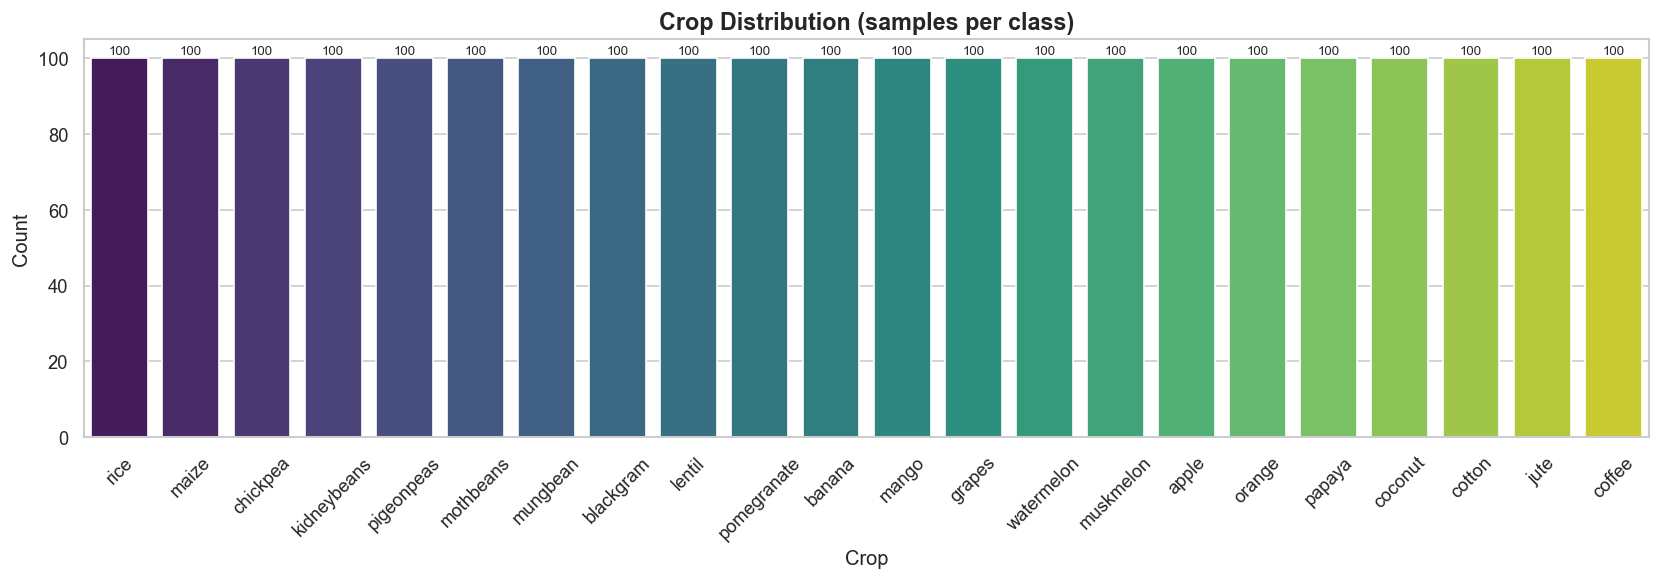

Dataset is balanced: True


In [5]:
# --- Crop class distribution ---
crop_counts = df['label'].value_counts()

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(x=crop_counts.index, y=crop_counts.values, palette='viridis', ax=ax)
ax.set_title('Crop Distribution (samples per class)', fontsize=14, fontweight='bold')
ax.set_xlabel('Crop')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()+1),
                ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Dataset is balanced:', crop_counts.std() < 1)
     

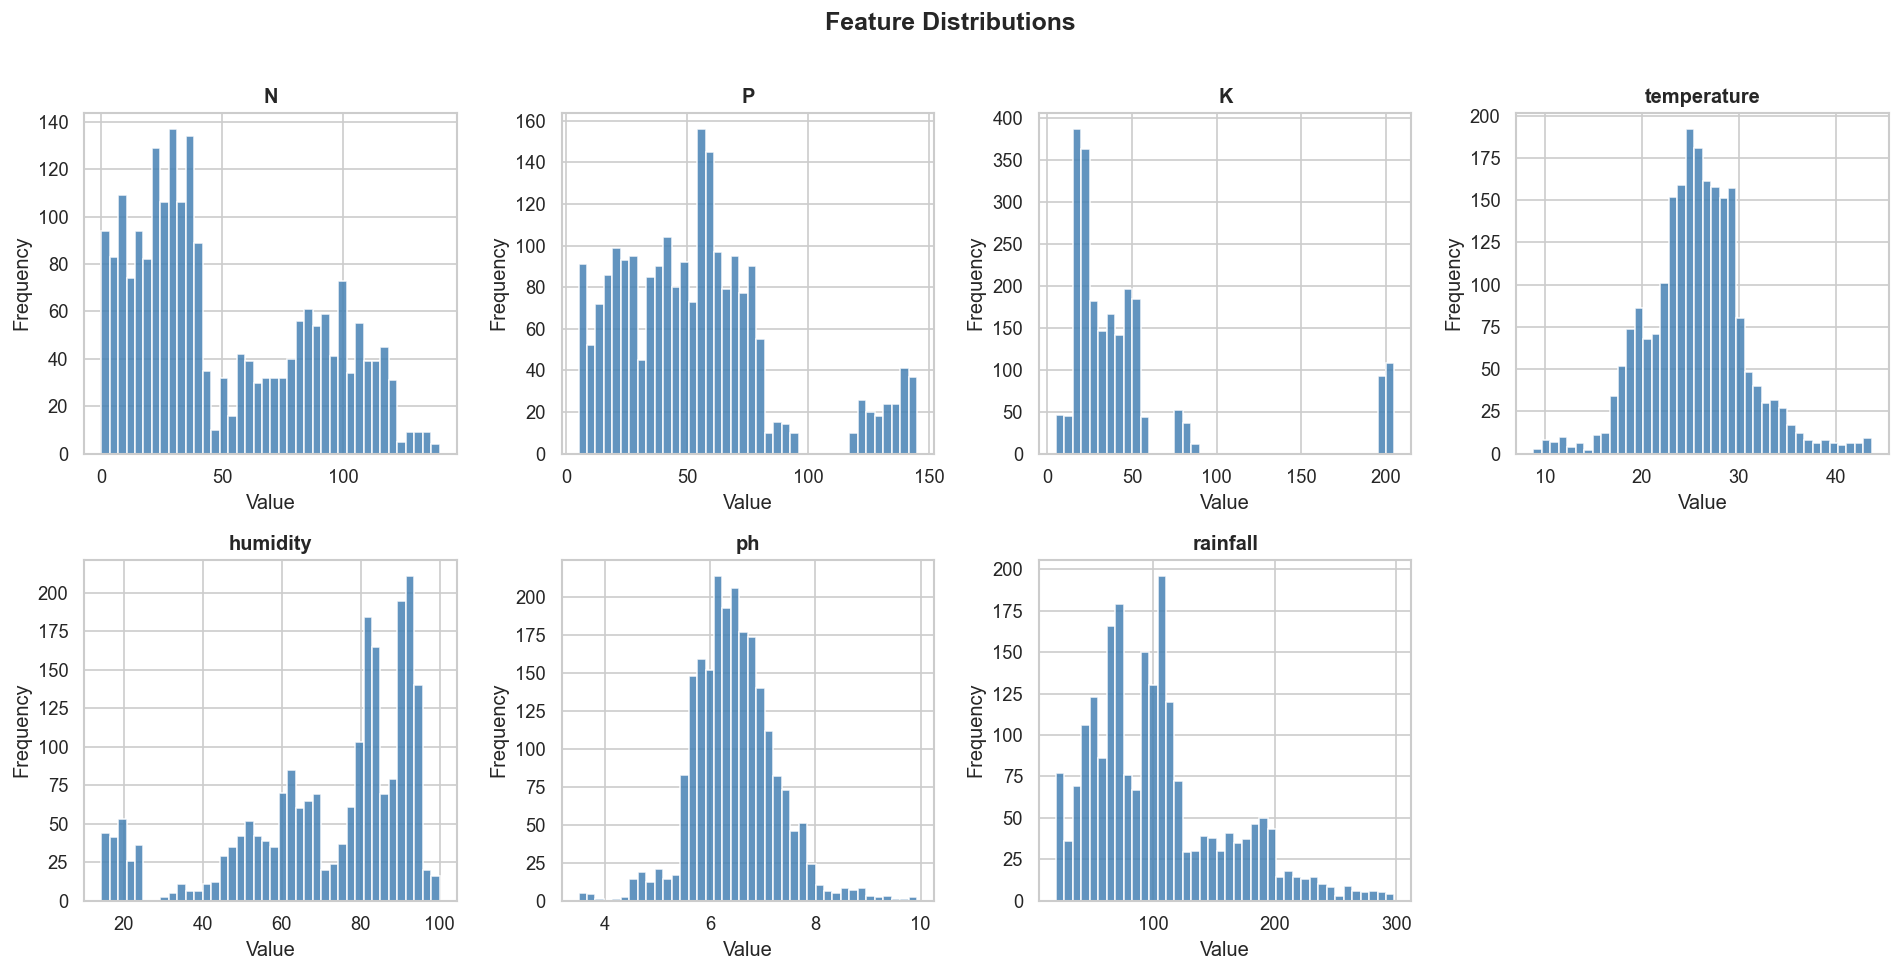

In [6]:
# --- Feature distributions ---
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')  # hide last empty subplot
fig.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
     


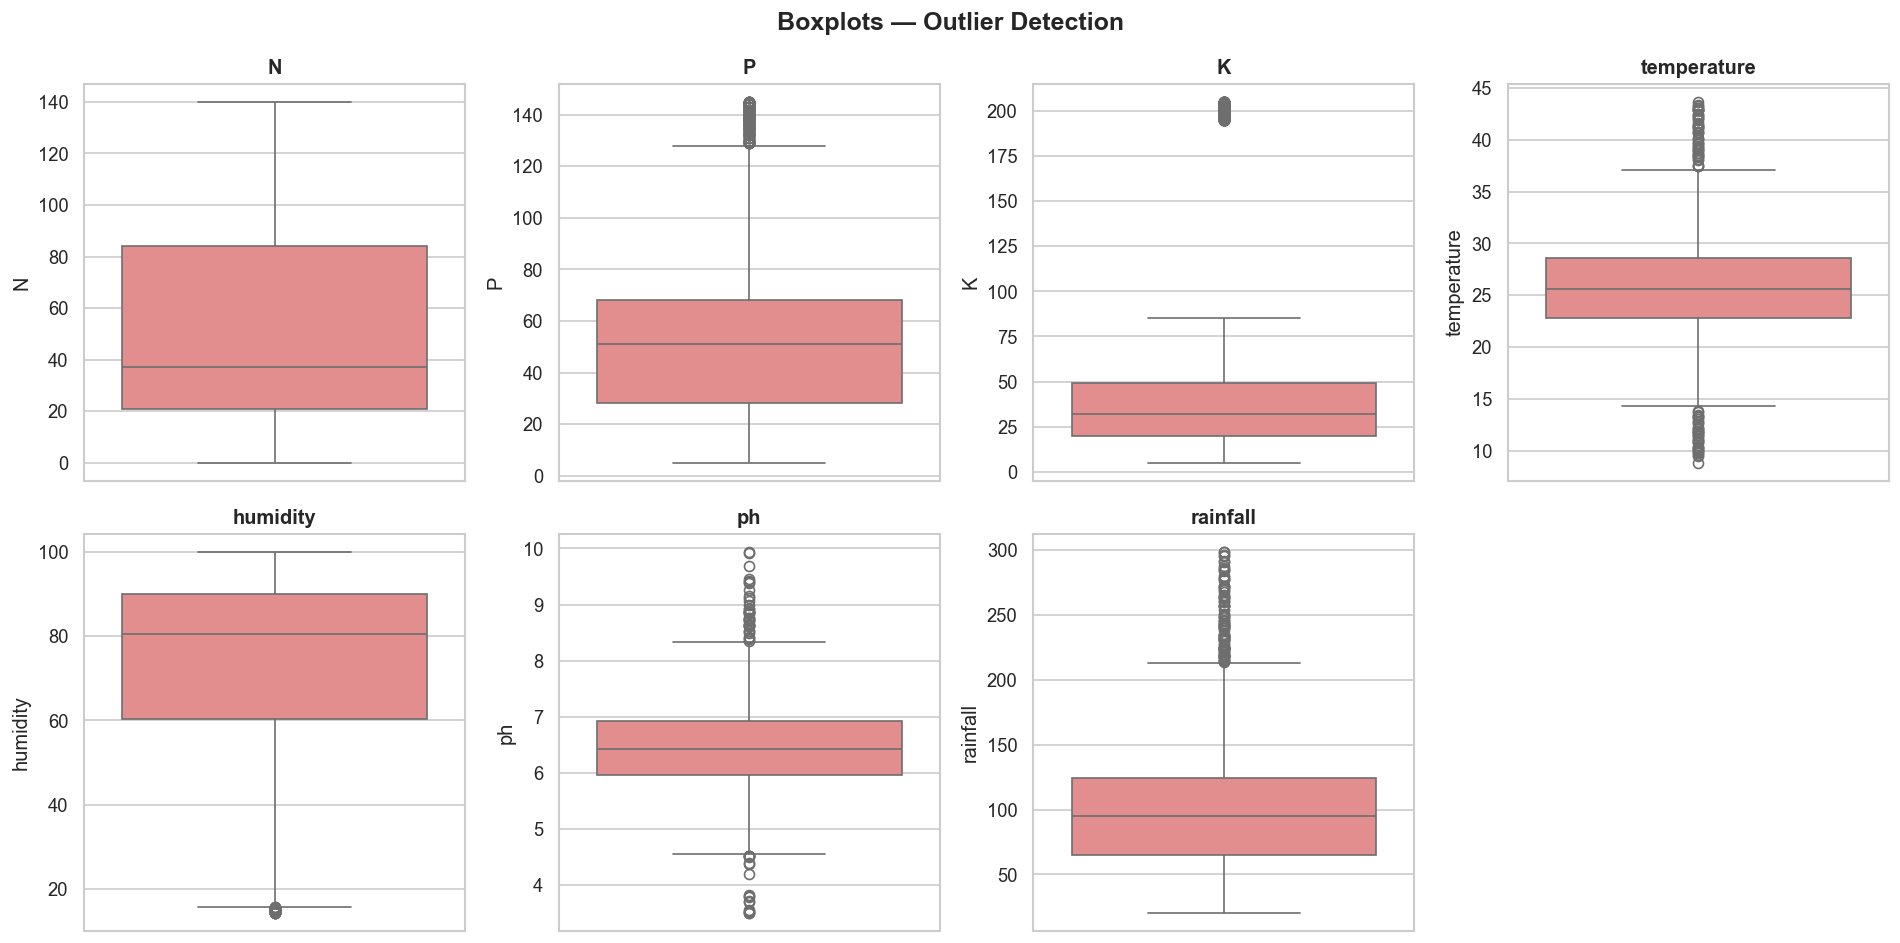

In [7]:
# --- Outlier detection with boxplots ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col, fontweight='bold')

axes[-1].axis('off')
fig.suptitle('Boxplots — Outlier Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
     

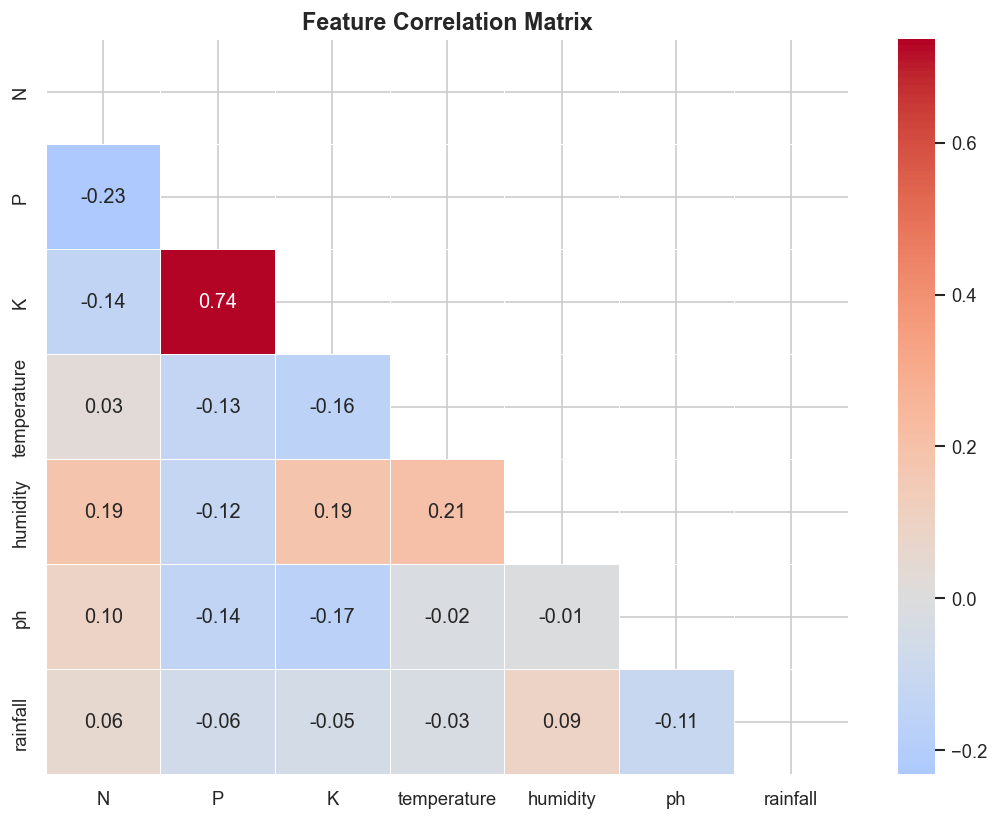

In [8]:
# --- Feature Correlation Heatmap ---
plt.figure(figsize=(9, 7))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
     

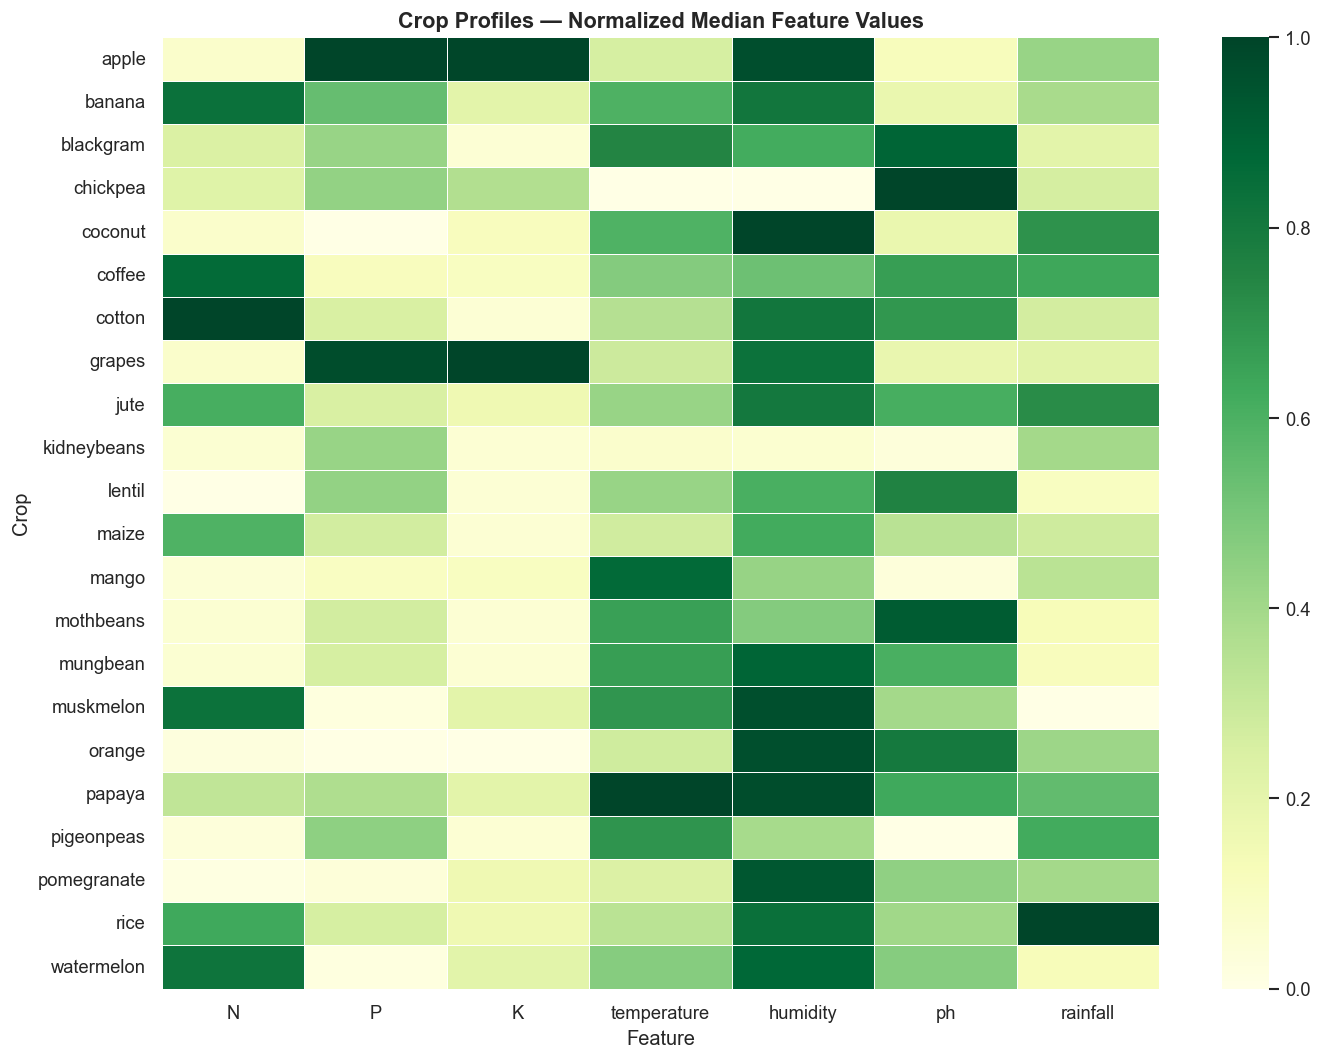

In [9]:
# --- Per-crop feature medians (heatmap) ---
crop_profile = df.groupby('label')[features].median()

# Normalize each feature for fair comparison
crop_profile_norm = (crop_profile - crop_profile.min()) / (crop_profile.max() - crop_profile.min())

plt.figure(figsize=(12, 9))
sns.heatmap(crop_profile_norm, annot=False, cmap='YlGn', linewidths=0.3)
plt.title('Crop Profiles — Normalized Median Feature Values', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

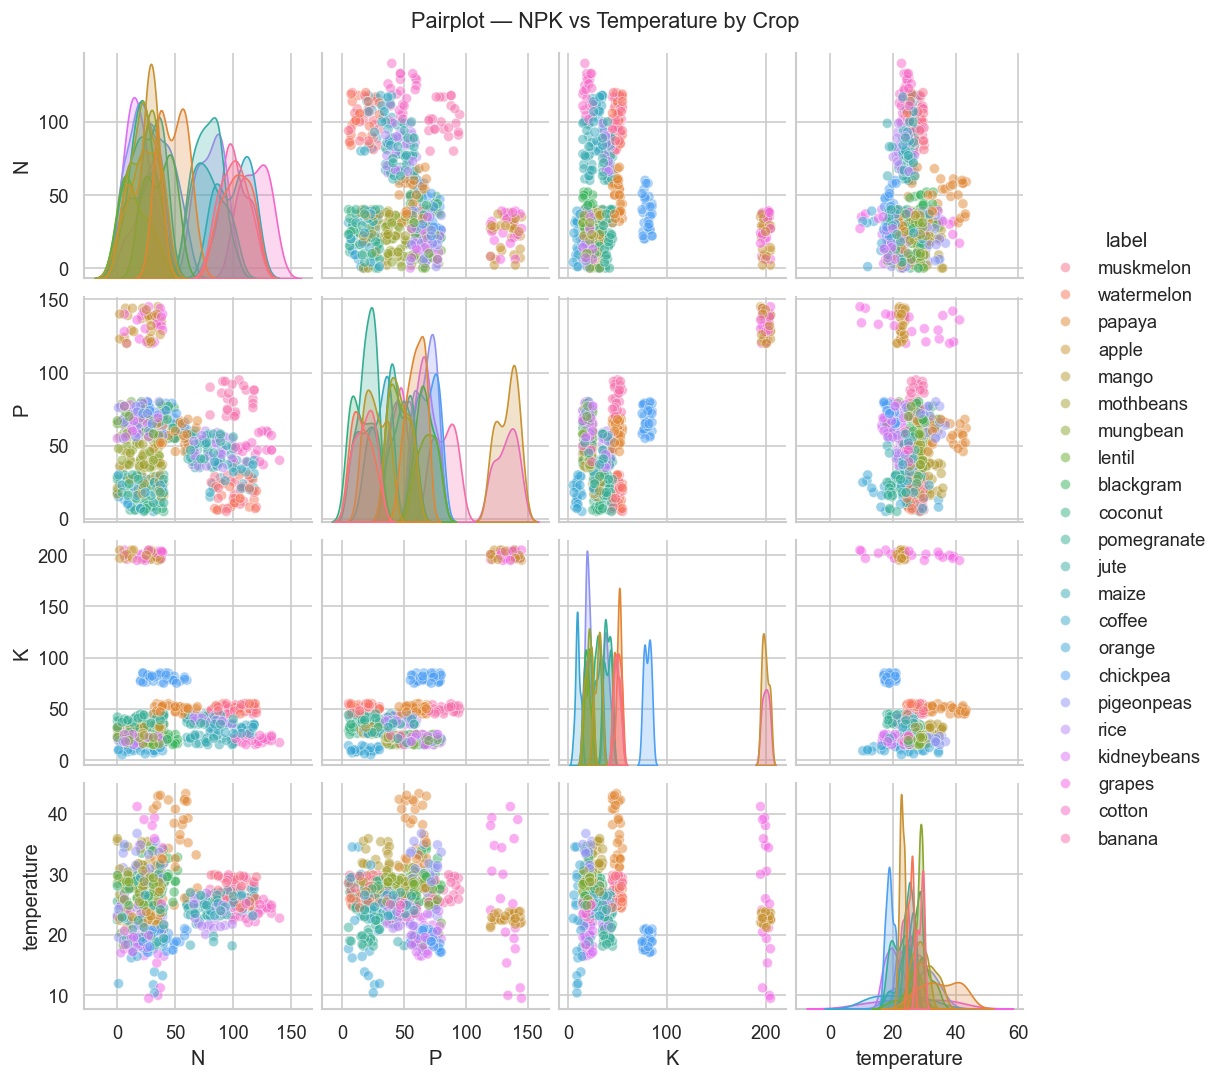

In [10]:
# --- Pairplot for key features (sampled) ---
sample = df.sample(600, random_state=42)
fig = sns.pairplot(sample[['N', 'P', 'K', 'temperature', 'label']],
                   hue='label', plot_kws={'alpha': 0.5}, height=2.2)
fig.figure.suptitle('Pairplot — NPK vs Temperature by Crop', y=1.02, fontsize=13)
plt.show()
     

## 4. Preprocessing

In [11]:
X = df.drop('label', axis=1)
y_raw = df['label']

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y_raw)

print('Classes:', list(le.classes_))
print('Encoded range:', y.min(), '→', y.max())

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified train/test split (preserves class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
     

Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']
Encoded range: 0 → 21

Train size: 1760 | Test size: 440


## 5. Model Comparison — Baseline

In [17]:
models = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', C=10, random_state=42),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = {'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std(), 'Test Acc': test_acc}
    print(f'{name:25s} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test: {test_acc:.4f}')

results_df = pd.DataFrame(results).T
print('\n', results_df)

Random Forest             | CV: 0.9955 ± 0.0032 | Test: 0.9955
Gradient Boosting         | CV: 0.9909 ± 0.0045 | Test: 0.9886
SVM (RBF)                 | CV: 0.9882 ± 0.0036 | Test: 0.9886
KNN (k=5)                 | CV: 0.9714 ± 0.0068 | Test: 0.9795

                     CV Mean    CV Std  Test Acc
Random Forest      0.995455  0.003214  0.995455
Gradient Boosting  0.990909  0.004545  0.988636
SVM (RBF)          0.988182  0.003636  0.988636
KNN (k=5)          0.971364  0.006833  0.979545


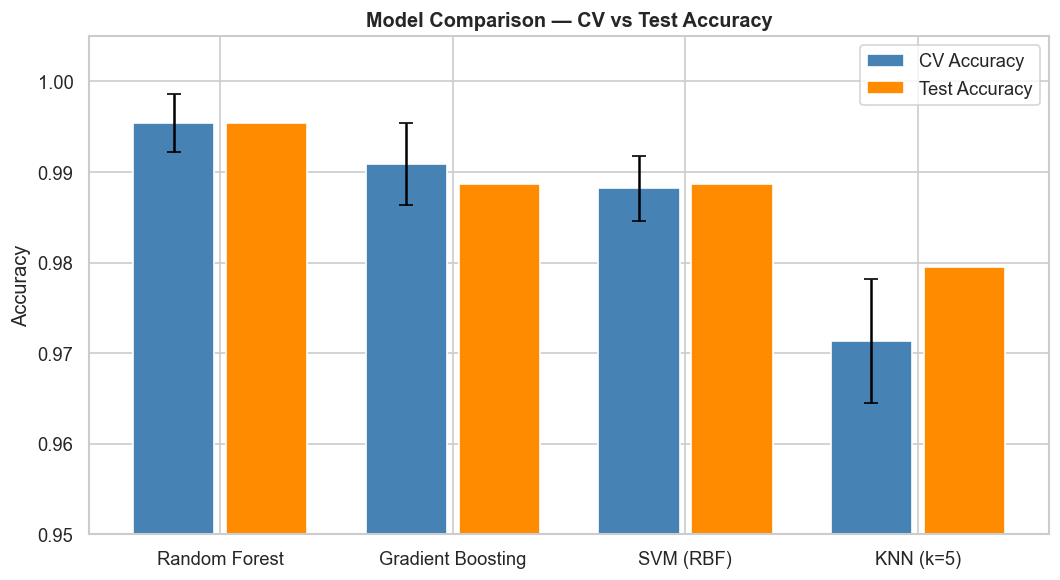

In [13]:
# --- Visualize model comparison ---
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(results_df))
bars = ax.bar(x - 0.2, results_df['CV Mean'], width=0.35, label='CV Accuracy',
               color='steelblue', yerr=results_df['CV Std'], capsize=4)
ax.bar(x + 0.2, results_df['Test Acc'], width=0.35, label='Test Accuracy',
       color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(results_df.index)
ax.set_ylim(0.95, 1.005)
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison — CV vs Test Accuracy', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
     


## 6. Hyperparameter Tuning — Random Forest

In [18]:
param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gs.fit(X_train, y_train)

print('Best parameters:', gs.best_params_)
print('Best CV accuracy:', f'{gs.best_score_:.4f}')

best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)
print('Test accuracy (tuned):', f'{accuracy_score(y_test, y_pred):.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV accuracy: 0.9960
Test accuracy (tuned): 0.9955


## 7. Final Evaluation

In [19]:
print('=== Classification Report ===')
target_names = le.classes_
print(classification_report(y_test, y_pred, target_names=target_names))

=== Classification Report ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        

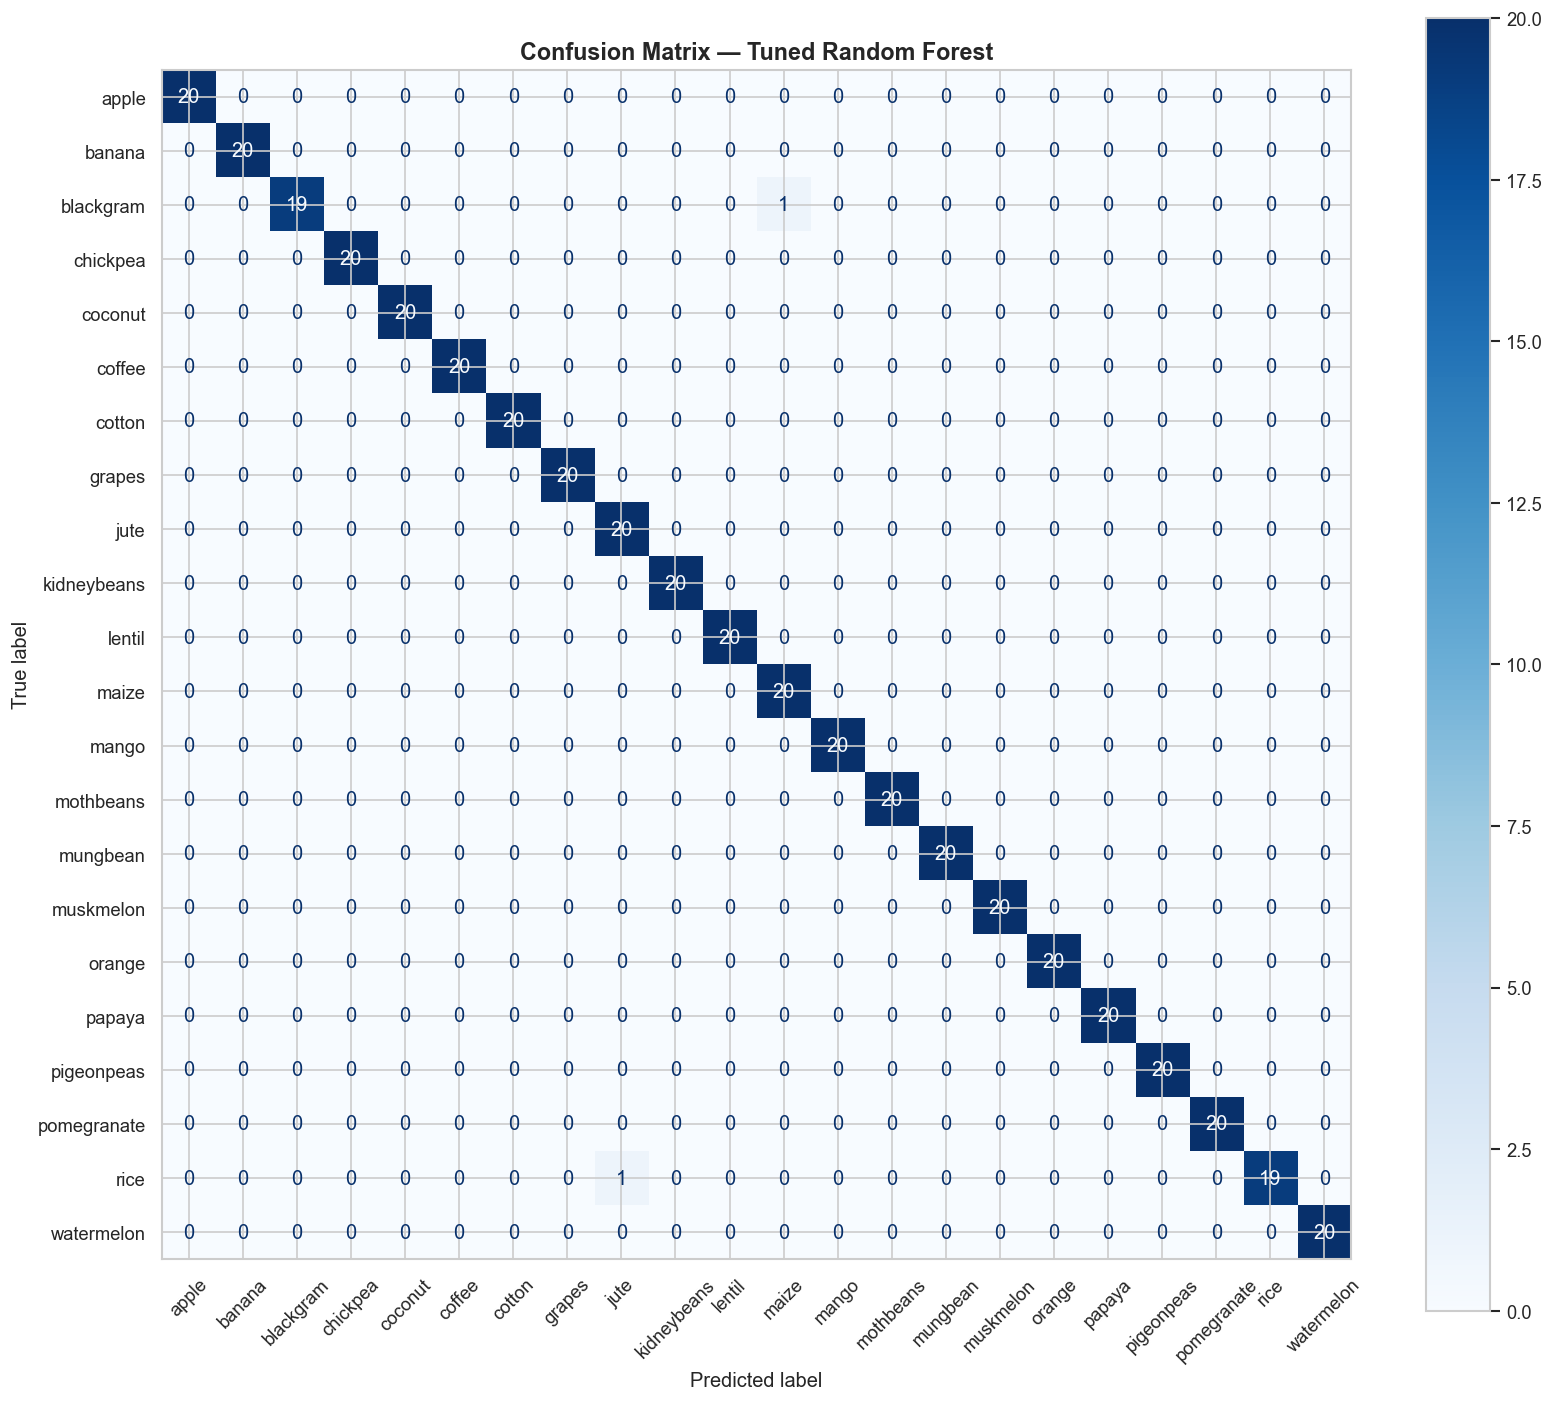

In [20]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix — Tuned Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

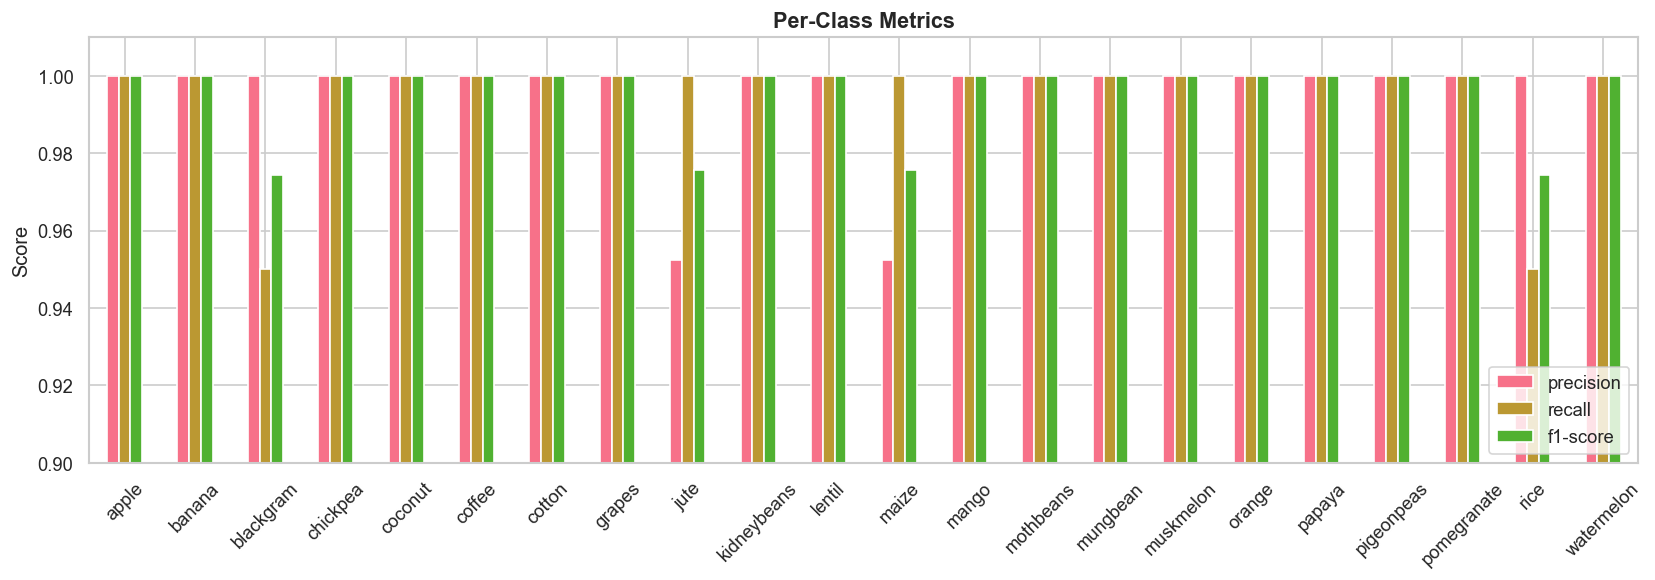

In [21]:
# --- Per-class accuracy bar chart ---
report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
per_class = pd.DataFrame(report).T.loc[target_names, ['precision', 'recall', 'f1-score']]

per_class.plot(kind='bar', figsize=(14, 5), edgecolor='white')
plt.title('Per-Class Metrics', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.9, 1.01)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
     

## 8. Feature Importance

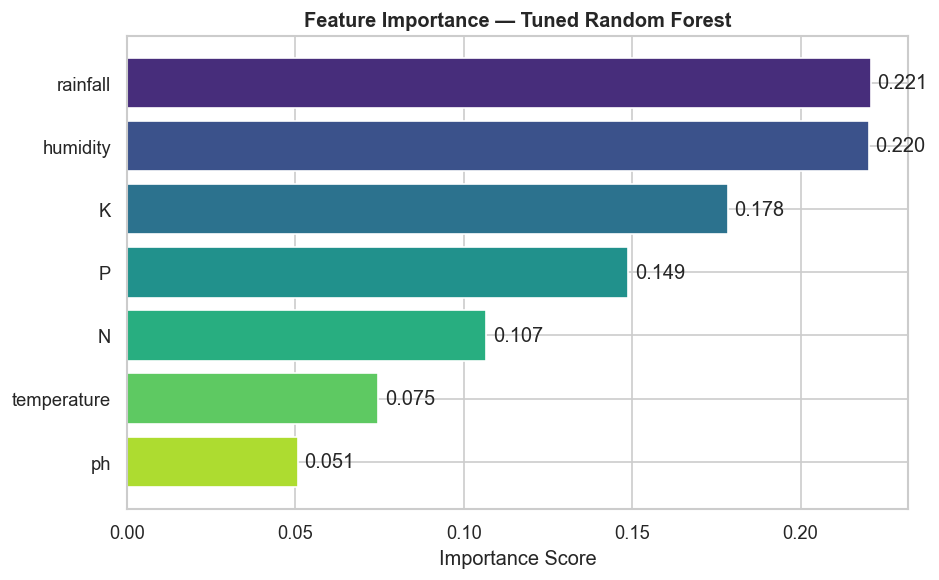

    Feature  Importance
   rainfall    0.220753
   humidity    0.220182
          K    0.178327
          P    0.148808
          N    0.106676
temperature    0.074563
         ph    0.050691


In [22]:
importances = best_model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('viridis', len(feat_df))
ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Tuned Random Forest', fontweight='bold')
for i, (v, label) in enumerate(zip(feat_df['Importance'], feat_df['Feature'])):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

## 9. Model Export

In [26]:
import os

save_dir = os.path.dirname(os.path.abspath('app.py'))  # same folder as app.py

pickle.dump(best_model, open(os.path.join(save_dir, 'model.pkl'), 'wb'))
pickle.dump(scaler,     open(os.path.join(save_dir, 'scaler.pkl'), 'wb'))
pickle.dump(le,         open(os.path.join(save_dir, 'label_encoder.pkl'), 'wb'))

print('Saved to:', save_dir)
     

Saved to: C:\Users\fariq


## 10. Quick Prediction Test

In [28]:
# Load saved artifacts and run a test prediction
model_loaded  = pickle.load(open('model.pkl', 'rb'))
scaler_loaded = pickle.load(open('scaler.pkl', 'rb'))
le_loaded     = pickle.load(open('label_encoder.pkl', 'rb'))

# Sample input: [N, P, K, temperature, humidity, ph, rainfall]
test_input = np.array([[90, 42, 43, 20.8, 82.0, 6.5, 202.9]])

scaled_input = scaler_loaded.transform(test_input)
prediction   = model_loaded.predict(scaled_input)
probabilities = model_loaded.predict_proba(scaled_input)[0]

crop_name = le_loaded.inverse_transform(prediction)[0]
confidence = probabilities[prediction[0]]

print(f'🌾 Predicted Crop : {crop_name}')
print(f'   Confidence     : {confidence:.2%}')

# Top 3 recommendations
top3_idx = np.argsort(probabilities)[::-1][:3]
print('\nTop 3 Recommendations:')
for rank, idx in enumerate(top3_idx, 1):
    print(f'  {rank}. {le_loaded.classes_[idx]:15s} ({probabilities[idx]:.2%})')

🌾 Predicted Crop : rice
   Confidence     : 90.78%

Top 3 Recommendations:
  1. rice            (90.78%)
  2. jute            (8.52%)
  3. papaya          (0.69%)
